# Import All Libraries

In [10]:
!pip install tensorflow numpy scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score

import numpy as np
import pickle
import json
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    TimeDistributed, Dropout, Bidirectional
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TF version:", tf.__version__)

TF version: 2.20.0


# Loading Dataset

In [2]:
from google.colab import files
files.upload()

Saving kaggle (3).json to kaggle (3).json


{'kaggle (3).json': b'{"username":"samichohan","key":"1db08c97bf829857ea9792b6c7269e38"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
# Change 'kaggle.json' to 'kaggle (3).json' to match the uploaded file name
os.rename('kaggle (3).json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
!kaggle datasets download -d alaakhaled/conll003-englishversion
!unzip -o conll003-englishversion.zip -d /content/conll2003_data
print("Files:", os.listdir('/content/conll2003_data'))

Dataset URL: https://www.kaggle.com/datasets/alaakhaled/conll003-englishversion
License(s): CC0-1.0
100% 960k/960k [00:00<00:00, 93.9MB/s]

Archive:  conll003-englishversion.zip
  inflating: /content/conll2003_data/metadata  
  inflating: /content/conll2003_data/test.txt  
  inflating: /content/conll2003_data/train.txt  
  inflating: /content/conll2003_data/valid.txt  
Files: ['valid.txt', 'test.txt', 'metadata', 'train.txt']


# Data Preprocessing

In [4]:
def load_conll_file(filepath):
    sentences, labels = [], []
    current_words, current_labels = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == "" or line.startswith("-DOCSTART-"):
                if current_words:
                    sentences.append(current_words)
                    labels.append(current_labels)
                    current_words, current_labels = [], []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current_words.append(parts[0])
                    current_labels.append(parts[-1])
    if current_words:
        sentences.append(current_words)
        labels.append(current_labels)
    return sentences, labels

train_sentences, train_labels = load_conll_file('/content/conll2003_data/train.txt')
val_sentences,   val_labels   = load_conll_file('/content/conll2003_data/valid.txt')
test_sentences,  test_labels  = load_conll_file('/content/conll2003_data/test.txt')

print(f"Train: {len(train_sentences)}, Val: {len(val_sentences)}, Test: {len(test_sentences)}")
print("Labels check:", train_labels[0])


Train: 14041, Val: 3250, Test: 3453
Labels check: ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


In [5]:
print(train_labels[1])

['B-PER', 'I-PER']


# Apply Vocabulary

In [11]:
all_labels = sorted(set(l for seq in train_labels + val_labels + test_labels for l in seq))
label2idx = {l: i for i, l in enumerate(all_labels)}
idx2label = {i: l for l, i in label2idx.items()}
num_labels = len(all_labels)
print("Labels:", all_labels)


word2idx = {"PAD": 0, "UNK": 1}
idx = 2
for sent in train_sentences + val_sentences + test_sentences:
    for word in sent:
        w = word.lower()
        if w not in word2idx:
            word2idx[w] = idx
            idx += 1

vocab_size = len(word2idx)
print(f"Vocab size: {vocab_size}")


print("barack in vocab:", "barack" in word2idx)
print("obama in vocab:", "obama" in word2idx)
print("elon in vocab:", "elon" in word2idx)
print("tesla in vocab:", "tesla" in word2idx)

Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
Vocab size: 26871
barack in vocab: False
obama in vocab: False
elon in vocab: False
tesla in vocab: False


# Apply Padding & One Hot Encoding & Data Separartion

In [12]:
MAX_LEN = 50

def prepare(sentences, labels):
    X = pad_sequences(
        [[word2idx.get(w.lower(), 1) for w in s] for s in sentences],
        maxlen=MAX_LEN, padding='post', value=0
    )
    y_pad = pad_sequences(
        [[label2idx[l] for l in seq] for seq in labels],
        maxlen=MAX_LEN, padding='post', value=0
    )
    return X, to_categorical(y_pad, num_classes=num_labels)

X_train, y_train = prepare(train_sentences, train_labels)
X_val,   y_val   = prepare(val_sentences,   val_labels)
X_test,  y_test  = prepare(test_sentences,  test_labels)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_train: (14041, 50), y_train: (14041, 50, 9)


# Data Modeling With LSTM

In [13]:
inp = Input(shape=(MAX_LEN,))
emb = Embedding(vocab_size, 64, mask_zero=True)(inp)
x   = Bidirectional(LSTM(128, return_sequences=True))(emb)
x   = Dropout(0.3)(x)
x   = Bidirectional(LSTM(64, return_sequences=True))(x)
x   = Dropout(0.3)(x)
out = TimeDistributed(Dense(num_labels, activation='softmax'))(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 64)    │  1,719,744 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 50)        │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 50, 256)   │    197,632 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 256)   │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 50, 128)   │    164,352 │ dropout_2[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 128)   │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 50, 9)     │      1,161 │ dropout_3[0][0],  │
│ (TimeDistributed)   │                   │            │ not_equal_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,082,889 (7.95 MB)

 Trainable params: 2,082,889 (7.95 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def make_sample_weights(y, label2idx):
    y_idx = np.argmax(y, axis=-1)
    o_idx = label2idx["O"]
    return np.where(y_idx == o_idx, 0.1, 1.0).astype(np.float32)

sample_weights = make_sample_weights(y_train, label2idx)

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    sample_weight=sample_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 150s 317ms/step - accuracy: 0.8235 - loss: 0.3025 - val_accuracy: 0.9210 - val_loss: 0.2738 - learning_rate: 0.0010
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 138s 315ms/step - accuracy: 0.9440 - loss: 0.0717 - val_accuracy: 0.9333 - val_loss: 0.2206 - learning_rate: 0.0010
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 315ms/step - accuracy: 0.9701 - loss: 0.0337 - val_accuracy: 0.9321 - val_loss: 0.2191 - learning_rate: 0.0010
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 321ms/step - accuracy: 0.9794 - loss: 0.0214 - val_accuracy: 0.9423 - val_loss: 0.1996 - learning_rate: 0.0010
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 140s 316ms/step - accuracy: 0.9848 - loss: 0.0155 - val_accuracy: 0.9400 - val_loss: 0.2126 - learning_rate: 0.0010
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9891 - loss: 0.0102
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
439/439 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy:

# Graph Representation Training Loss & Validation Loss

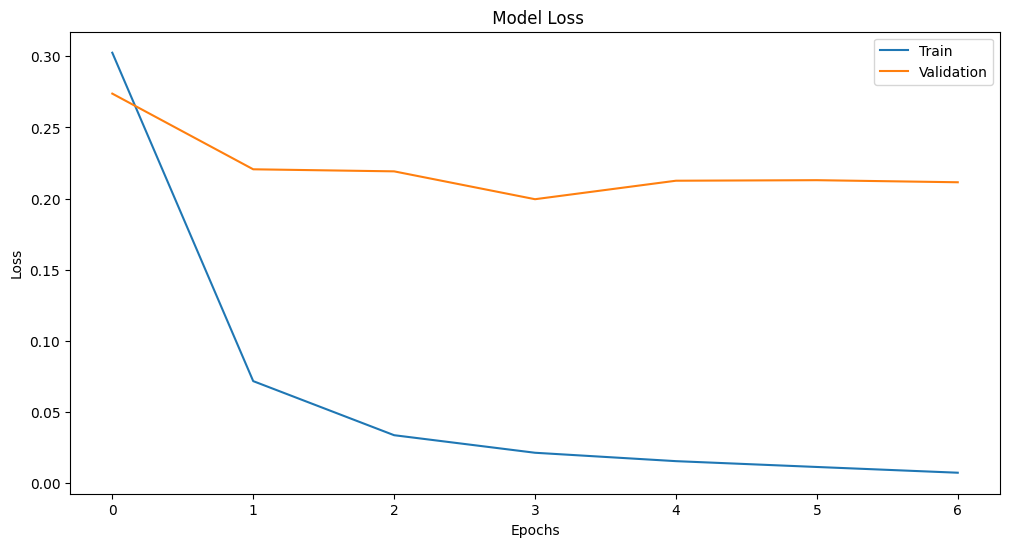

In [27]:
plt.figure(figsize=(12,6))
plt.title(' Model Loss')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

# Graph Representation Training Accuracy & Validation Accuracy

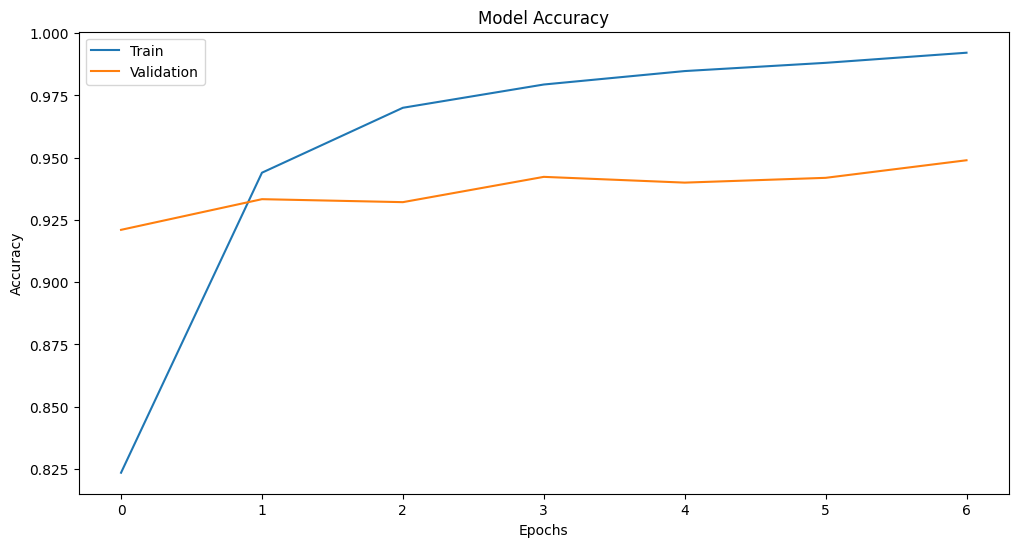

In [28]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

# Evaluation: Calculation of Test Loss & Accuracy

In [29]:
test_loss,test_accuracy = model.evaluate(X_test,y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.9161 - loss: 0.3239
Test Loss: 0.3238629400730133
Test Accuracy: 0.9161012768745422


# Model Evaluate

In [18]:
y_pred = model.predict(X_test)

y_pred_labels = []
y_true_labels = []

for i in range(len(X_test)):
  pred_seq = []
  true_seq = []
  for j in range(MAX_LEN):
    if X_test[i][j] != 0:
      pred_label = idx2label[np.argmax(y_pred[i][j])]
      true_label = idx2label[np.argmax(y_test[i][j])]
      pred_seq.append(pred_label)
      true_seq.append(true_label)

  y_pred_labels.extend(pred_seq)
  y_true_labels.extend(true_seq)

# Classification Report
print("/n Classification Report:")
print(classification_report(y_true_labels,y_pred_labels))

108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step
/n Classification Report:
              precision    recall  f1-score   support

       B-LOC       0.80      0.85      0.82      1653
      B-MISC       0.58      0.75      0.65       701
       B-ORG       0.62      0.72      0.67      1655
       B-PER       0.79      0.76      0.77      1579
       I-LOC       0.34      0.82      0.48       256
      I-MISC       0.34      0.64      0.44       216
       I-ORG       0.60      0.70      0.64       834
       I-PER       0.77      0.87      0.82      1114
           O       0.98      0.95      0.96     38143

    accuracy                           0.92     46151
   macro avg       0.65      0.78      0.70     46151
weighted avg       0.93      0.92      0.92     46151



# Model Testing : Real Time Prediction

In [19]:
def predict_entities(sentence, model, word2idx, idx2label, max_len=50):

    words = sentence.split()

    # Words  numbers  convert
    word_ids = [word2idx.get(w.lower(), 1) for w in words]

    # Padding
    padded = pad_sequences([word_ids], maxlen=max_len, padding='post')

    # Prediction
    pred = model.predict(padded, verbose=0)
    pred_labels = [idx2label[np.argmax(pred[0][i])] for i in range(len(words))]

    return list(zip(words, pred_labels))

# Test
test_sentence = '''Bill Gates worked at Microsoft in New York City,
               Mark Zuckerberg created Facebook in California in 2004'''

result = predict_entities(test_sentence, model, word2idx, idx2label)

print("\nTest Result:")
print(f"Sentence: {test_sentence}\n")
for word, label in result:
    if label != 'O':
        print(f"  '{word}' → {label} ")
    else:
        print(f"  '{word}' → {label}")


Test Result:
Sentence: Bill Gates worked at Microsoft in New York City,
               Mark Zuckerberg created Facebook in California in 2004

  'Bill' → B-PER 
  'Gates' → I-PER 
  'worked' → O
  'at' → O
  'Microsoft' → B-ORG 
  'in' → O
  'New' → B-LOC 
  'York' → I-LOC 
  'City,' → I-LOC 
  'Mark' → B-PER 
  'Zuckerberg' → I-PER 
  'created' → I-PER 
  'Facebook' → I-PER 
  'in' → O
  'California' → B-LOC 
  'in' → O
  '2004' → O


In [20]:
def quick_test(sentence):
    words = sentence.split()
    ids = [word2idx.get(w.lower(), 1) for w in words]
    padded = pad_sequences([ids], maxlen=MAX_LEN, padding='post')
    pred = model.predict(padded, verbose=0)
    print(f"\nSentence: {sentence}")
    for i, word in enumerate(words):
        label = idx2label[np.argmax(pred[0][i])]
        marker = "" if label != "O" else ""
        print(f"  {word:15} → {label} {marker}")

quick_test("Barack Obama was President of United States")
quick_test("Elon Musk founded Tesla in California")
quick_test("Imran Khan visited Karachi and met UN officials")



Sentence: Barack Obama was President of United States
  Barack          → B-PER 
  Obama           → I-PER 
  was             → O 
  President       → O 
  of              → O 
  United          → B-LOC 
  States          → I-LOC 

Sentence: Elon Musk founded Tesla in California
  Elon            → B-PER 
  Musk            → I-PER 
  founded         → O 
  Tesla           → B-LOC 
  in              → O 
  California      → B-LOC 

Sentence: Imran Khan visited Karachi and met UN officials
  Imran           → B-PER 
  Khan            → I-PER 
  visited         → O 
  Karachi         → B-LOC 
  and             → O 
  met             → O 
  UN              → B-ORG 
  officials       → O 


In [21]:
os.makedirs('/content/model', exist_ok=True)
model.save('/content/model/ner_model.keras')

with open('/content/model/word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
with open('/content/model/idx2label.pkl', 'wb') as f:
    pickle.dump(idx2label, f)

config = {"max_len": MAX_LEN, "num_labels": num_labels, "vocab_size": vocab_size, "label_names": all_labels}
with open('/content/model/config.json', 'w') as f:
    json.dump(config, f)

import shutil
shutil.make_archive('/content/model_files', 'zip', '/content/model')
files.download('/content/model_files.zip')
print("Download ho raha hai!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download ho raha hai!


In [22]:
import os

In [23]:
quick_test("Barack Obama was President of United States")
quick_test("Elon Musk founded Tesla in California")
quick_test("Imran Khan visited Karachi")


Sentence: Barack Obama was President of United States
  Barack          → B-PER 
  Obama           → I-PER 
  was             → O 
  President       → O 
  of              → O 
  United          → B-LOC 
  States          → I-LOC 

Sentence: Elon Musk founded Tesla in California
  Elon            → B-PER 
  Musk            → I-PER 
  founded         → O 
  Tesla           → B-LOC 
  in              → O 
  California      → B-LOC 

Sentence: Imran Khan visited Karachi
  Imran           → B-PER 
  Khan            → I-PER 
  visited         → O 
  Karachi         → B-LOC 


In [24]:
# CELL 1
!pip install spacy -q
!python -m spacy download en_core_web_sm -q
print("Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done!


In [25]:
# CELL 2 — Model test karo
import spacy
nlp = spacy.load("en_core_web_sm")

test_sentences = [
    "Barack Obama was President of United States",
    "Elon Musk founded Tesla in California",
    "Imran Khan visited Karachi and met UN officials"
]

for sent in test_sentences:
    doc = nlp(sent)
    print(f"\nSentence: {sent}")
    for ent in doc.ents:
        print(f"  {ent.text:20} → {ent.label_}")


Sentence: Barack Obama was President of United States
  Barack Obama         → PERSON
  United States        → GPE

Sentence: Elon Musk founded Tesla in California
  Elon Musk            → PERSON
  Tesla                → ORG
  California           → GPE

Sentence: Imran Khan visited Karachi and met UN officials
  Khan                 → PERSON
  Karachi              → ORG
  UN                   → ORG


In [26]:
# CELL 3 — Save karo
import pickle, json, os
os.makedirs('/content/model', exist_ok=True)

# spaCy model save
nlp.to_disk('/content/model/spacy_model')

# Config save
config = {
    "model_type": "spacy",
    "model_name": "en_core_web_sm",
    "labels": ["PERSON", "ORG", "GPE", "LOC", "DATE", "MONEY", "TIME"]
}
with open('/content/model/config.json', 'w') as f:
    json.dump(config, f)

print("Saved!")

# Download
import shutil
from google.colab import files
shutil.make_archive('/content/model_files', 'zip', '/content/model')
files.download('/content/model_files.zip')

Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>